## Run a pipeline adding a custom algorithm

This process will run the entire pipeline described in a configuration file and will add a custom algorithm to it

## Import dependencies

In [2]:
%load_ext autoreload
%autoreload 2
from paidiverpy.pipeline import Pipeline

## Instantiate the Pipeline class

When you instantiate the pipeline class, it will install some dependencies described in the configuration file that are necessary for the custom algorithm

In [3]:
pipeline = Pipeline(config_file_path="../config_files/config_custom_algorithm.yaml")

This occurs because of the following step that you added in the conf file:

```
steps:
    ...

  - custom:
      name: "min_max_data"
      file_path: "/mnt/noc/code/paidiver/paidiverpy/examples/custom_algorithms/custom_algorithm_example.py"
      class_name: "MyMethod"
      dependencies:
        - "scikit-learn"
      params:
        feature_range: (0, 1)
```

In this case, you are saying that you need to install scikit-learn to use the custom algorithm

In [5]:
pipeline.config

{
    "general": {
        "name": "raw",
        "step_name": "open",
        "sample_data": "benthic_csv",
        "input_path": "/home/tobfer/.paidiverpy_cache/benthic_csv/images",
        "metadata_path": "/home/tobfer/.paidiverpy_cache/benthic_csv/metadata/metadata_benthic_csv.csv",
        "metadata_type": "CSV_FILE",
        "image_type": "PNG",
        "append_data_to_metadata": "/home/tobfer/.paidiverpy_cache/benthic_csv/metadata/appended_metadata_benthic_csv.csv",
        "is_remote": false,
        "output_is_remote": false,
        "output_path": "output",
        "n_jobs": 1,
        "client": null,
        "track_changes": true,
        "rename": "datetime",
        "sampling": [
            {
                "name": "sampling",
                "step_name": "sampling",
                "mode": "percent",
                "test": false,
                "params": {
                    "value": 0.1,
                    "raise_error": false
                }
            }
     

In [6]:
# See the pipeline steps. Click in a step to see more information about it
pipeline

In [7]:
# See the pipeline steps in json format
pipeline.steps

[('raw',
  paidiverpy.open_layer.open_layer.OpenLayer,
  {'name': 'raw',
   'step_name': 'open',
   'sample_data': 'benthic_csv',
   'input_path': PosixPath('/home/tobfer/.paidiverpy_cache/benthic_csv/images'),
   'metadata_path': PosixPath('/home/tobfer/.paidiverpy_cache/benthic_csv/metadata/metadata_benthic_csv.csv'),
   'metadata_type': 'CSV_FILE',
   'image_type': 'PNG',
   'append_data_to_metadata': '/home/tobfer/.paidiverpy_cache/benthic_csv/metadata/appended_metadata_benthic_csv.csv',
   'is_remote': False,
   'output_is_remote': False,
   'output_path': PosixPath('output'),
   'n_jobs': 1,
   'client': None,
   'track_changes': True,
   'rename': 'datetime',
   'sampling': [{'name': 'sampling',
     'step_name': 'sampling',
     'mode': 'percent',
     'test': False,
     'params': {'value': 0.1, 'raise_error': False}}],
   'convert': [{'name': 'convert',
     'step_name': 'convert',
     'mode': 'bits',
     'test': False,
     'params': {'output_bits': 8, 'raise_error': False

The `min_max_data` is a custom algorithm available in `file_path`: `/mnt/noc/code/paidiver/paidiverpy/examples/custom_algorithms/custom_algorithm_example.py`

In [8]:
# Run the pipeline
pipeline.run()

☁ paidiverpy ☁  |       INFO | 2025-02-12 13:38:13 | Processing images using 1 cores
☁ paidiverpy ☁  |       INFO | 2025-02-12 13:38:13 | Running step 0: raw - OpenLayer


Processing images: 100%|███████████████████████| 5/5 [00:00<00:00, 16804.10it/s]

☁ paidiverpy ☁  |       INFO | 2025-02-12 13:38:13 | Step 0 completed


☁ paidiverpy ☁  |       INFO | 2025-02-12 13:38:13 | Running step 1: colour_correction - ColourLayer


Processing images: 100%|████████████████████████| 5/5 [00:00<00:00, 2243.18it/s]

☁ paidiverpy ☁  |       INFO | 2025-02-12 13:38:13 | Step 1 completed


☁ paidiverpy ☁  |       INFO | 2025-02-12 13:38:13 | Running step 2: min_max_data - CustomLayer
☁ paidiverpy ☁  |       INFO | 2025-02-12 13:38:13 | Step 2 completed


Step: raw
Image: [[[96 76 89  1]
  [96 76 87  1]
  [94 76 87  1]
  ...
  [94 53 50  1]
  [93 51 49  1]
  [95 52 50  1]]

 [[92 75 86  1]
  [95 76 86  1]
  [94 76 87  1]
  ...
  [94 51 49  1]
  [95 52 49  1]
  [93 52 48  1]]

 [[94 76 88  1]
  [91 75 86  1]
  [92 75 84  1]
  ...
  [92 51 48  1]
  [93 52 49  1]
  [93 51 47  1]]

 ...

 [[86 64 65  1]
  [86 62 65  1]
  [86 62 62  1]
  ...
  [87 48 41  1]
  [85 46 43  1]
  [86 47 41  1]]

 [[84 63 63  1]
  [85 61 63  1]
  [86 63 63  1]
  ...
  [88 49 43  1]
  [87 47 43  1]
  [85 48 44  1]]

 [[82 61 63  1]
  [86 62 62  1]
  [86 63 63  1]
  ...
  [88 49 42  1]
  [87 49 42  1]
  [85 48 41  1]]]
Image: [[[81 53 60  1]
  [80 53 58  1]
  [80 53 57  1]
  ...
  [90 50 46  1]
  [91 48 45  1]
  [89 48 45  1]]

 [[77 53 56  1]
  [80 54 58  1]
  [78 54 57  1]
  ...
  [89 48 45  1]
  [89 49 45  1]
  [86 48 43  1]]

 [[77 51 56  1]
  [77 52 55  1]
  [80 54 57  1]
  ...
  [88 48 43  1]
  [87 49 46  1]
  [86 48 43  1]]

 ...

 [[85 58 58  1]
  [82 58 57  1]
  [83 56 54  1]
  ...
  [84 48 45  1]
  [82 46 42  1]
  [81 47 43  1]]

 [[82 59 59  1]
  [82 58 58  1]
  [85 60 57  1]
  ...
  [83 47 43  1]
  [82 47 42  1]
  [82 47 42  1]]

 [[83 59 60  1]
  [84 60 58  1]
  [85 59 57  1]
  ...
  [84 49 45  1]
  [83 46 42  1]
  [80 47 42  1]]]
Image: [[[196 191 233   1]
  [195 191 233   1]
  [193 187 232   1]
  ...
  [187 175 217   1]
  [187 178 220   1]
  [186 177 220   1]]

 [[195 190 237   1]
  [195 190 233   1]
  [193 190 235   1]
  ...
  [187 175 218   1]
  [184 177 219   1]
  [187 178 223   1]]

 [[191 188 233   1]
  [194 191 234   1]
  [192 189 233   1]
  ...
  [182 173 214   1]
  [183 174 216   1]
  [182 174 217   1]]

 ...

 [[210 208 242   1]
  [210 209 248   1]
  [152 144 121   1]
  ...
  [201 197 235   1]
  [199 196 232   1]
  [198 195 233   1]]

 [[211 207 238   1]
  [204 202 215   1]
  [130 119 102   1]
  ...
  [201 197 232   1]
  [203 196 237   1]
  [201 199 237   1]]

 [[216 214 244   1]
  [136 127 103   1]
  [132 119  94   1]
  ...
  [200 198 233   1]
  [199 198 234   1]
  [201 200 235   1]]]
Image: [[[191 184 232   1]
  [188 181 228   1]
  [190 185 230   1]
  ...
  [181 169 212   1]
  [183 174 218   1]
  [185 175 220   1]]

 [[189 181 229   1]
  [190 184 232   1]
  [187 183 232   1]
  ...
  [182 171 217   1]
  [186 178 223   1]
  [180 172 213   1]]

 [[190 184 231   1]
  [188 184 226   1]
  [193 188 235   1]
  ...
  [179 170 212   1]
  [182 178 219   1]
  [178 168 212   1]]

 ...

 [[211 210 245   1]
  [213 212 249   1]
  [155 148 127   1]
  ...
  [194 193 230   1]
  [200 198 233   1]
  [199 197 235   1]]

 [[212 210 241   1]
  [206 205 221   1]
  [130 119 101   1]
  ...
  [202 198 237   1]
  [200 197 236   1]
  [199 196 237   1]]

 [[218 219 247   1]
  [139 127 102   1]
  [129 118  94   1]
  ...
  [199 197 234   1]
  [203 201 238   1]
  [201 199 238   1]]]
Image: [[[193 187 231   1]
  [195 190 236   1]
  [193 187 231   1]
  ...
  [181 171 216   1]
  [187 177 222   1]
  [182 173 218   1]]

 [[191 182 225   1]
  [201 200 241   1]
  [189 182 229   1]
  ...
  [183 172 218   1]
  [179 170 216   1]
  [182 173 215   1]]

 [[193 188 233   1]
  [190 184 228   1]
  [195 200 240   1]
  ...
  [183 174 217   1]
  [181 173 215   1]
  [181 174 219   1]]

 ...

 [[208 206 245   1]
  [207 206 247   1]
  [161 153 132   1]
  ...
  [202 197 235   1]
  [197 194 233   1]
  [203 199 234   1]]

 [[210 208 237   1]
  [206 205 221   1]
  [131 122 105   1]
  ...
  [203 200 236   1]
  [202 198 232   1]
  [200 197 236   1]]

 [[215 215 245   1]
  [139 130 106   1]
  [133 121  98   1]
  ...
  [202 200 234   1]
  [201 199 235   1]
  [201 199 235   1]]]
Step: colour_correction
Image: [[82 82 81 ... 57 55 56]
 [80 81 81 ... 55 56 55]
 [82 80 80 ... 55 56 55]
 ...
 [67 66 65 ... 50 50 50]
 [65 64 66 ... 52 50 51]
 [64 65 66 ... 51 51 50]]
Image: [[58 58 57 ... 53 52 52]
 [57 58 58 ... 52 52 51]
 [55 56 58 ... 51 52 51]
 ...
 [61 60 58 ... 51 49 50]
 [62 61 62 ... 50 49 49]
 [62 62 61 ... 52 49 49]]
Image: [[204 204 201 ..
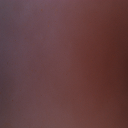
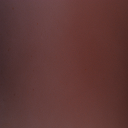
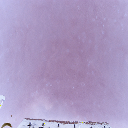
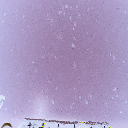
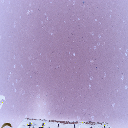
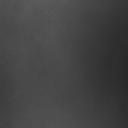
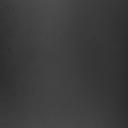
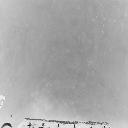
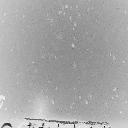
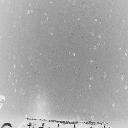
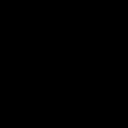
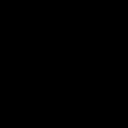
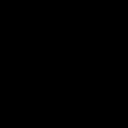
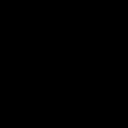
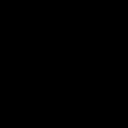

In [9]:
# See the images output
pipeline.images